<a href="https://colab.research.google.com/github/ChanggonSong/AI-Study/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanic.csv', index_col = 0)
features

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [18]:
# 문자열을 숫자로
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
features['Sex'] = le.fit_transform(features['Sex'])
features['Embarked'] = le.fit_transform(features['Embarked'])

features.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


In [19]:
# 결측치 개수 파악
# 셀 실행 결과를 데이터프레임으로 보고 싶을 때 to_frame()과 pd.DataFrame() 두 가지를 사용 가능
features.isnull().sum().to_frame('nan_count')

,nan_count
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [20]:
# 결측치 비율 파악
pd.DataFrame(data=features.isnull().sum()/len(features),columns=['nan_ratio'])

,nan_ratio
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Cabin,0.771044


In [21]:
# 결측치가 있는 열의 평균값으로 채우기(Cabin은 버림)
# 원하는 열들 선택
selected_columns = ['Age', 'Embarked']

# 선택한 열들의 결측치를 해당 열의 평균값으로 채우기
for column in selected_columns:
    features[column] = features[column].fillna(features[column].mean())

In [22]:
y = features['Survived']
y

PassengerId
1      0
2      1
3      1
4      1
5      0
      ..
887    0
888    1
889    0
890    1
891    0
Name: Survived, Length: 891, dtype: int64

In [23]:
features.dtypes

Survived      int64
Pclass        int64
Name         object
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked      int64
dtype: object

In [24]:
columns_to_drop = ['Survived', 'Ticket', 'Cabin', 'Name']
X = features.drop(columns=columns_to_drop, axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,
1,3,1,22.000000,1,0,7.2500,2
2,1,0,38.000000,1,0,71.2833,0
3,3,0,26.000000,0,0,7.9250,2
4,1,0,35.000000,1,0,53.1000,2
5,3,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...
887,2,1,27.000000,0,0,13.0000,2
888,1,0,19.000000,0,0,30.0000,2
889,3,0,29.699118,1,2,23.4500,2


In [25]:
passenger_target = y.to_numpy()
passenger_full = X.to_numpy()

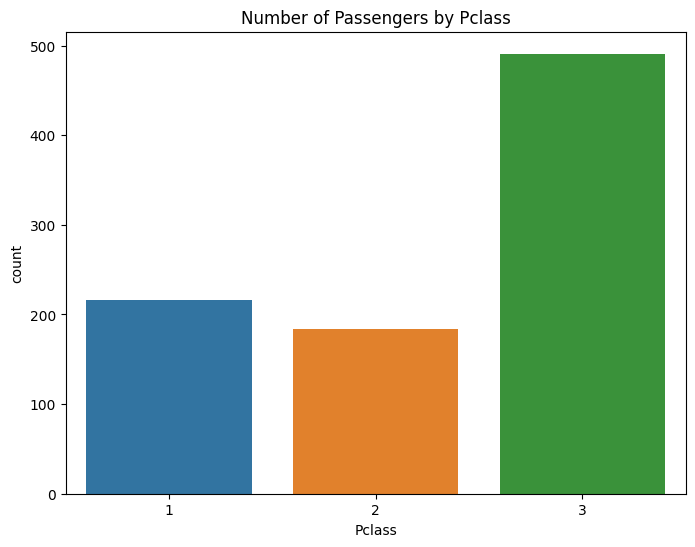

In [26]:
# 1. Pclass 레이블별 갯수 및 차트 표시
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', data=features)
plt.title('Number of Passengers by Pclass')
plt.show()

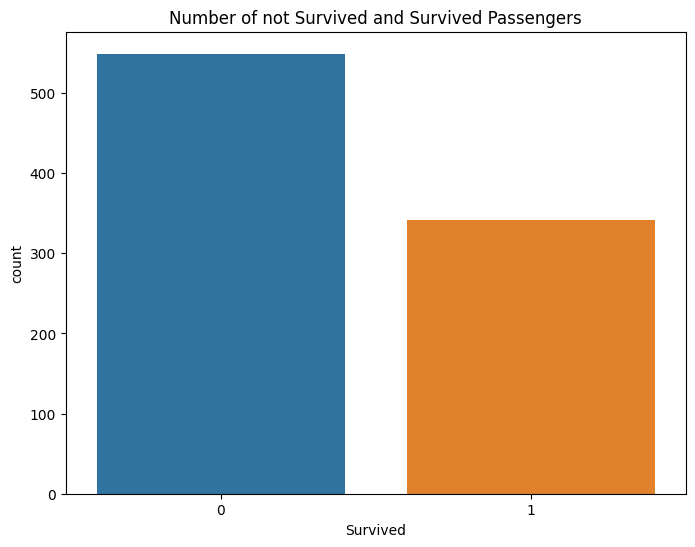

In [27]:
# 2. 생존자와 사망자 총 숫자 및 차트 표시 (1: Survived)
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=features)
plt.title('Number of not Survived and Survived Passengers')
plt.show()

#### 3. 성별, 티켓클래스(Pclass), 생존여부(Survived) 상관관계 분석

In [48]:
features.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

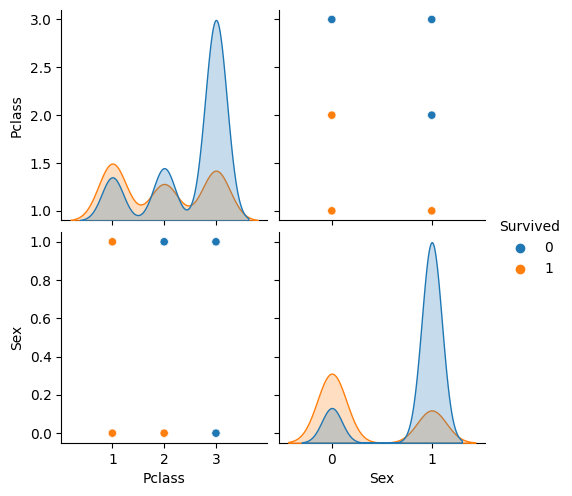

In [50]:
sns.pairplot(features, vars=['Pclass', 'Sex'], hue="Survived")
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


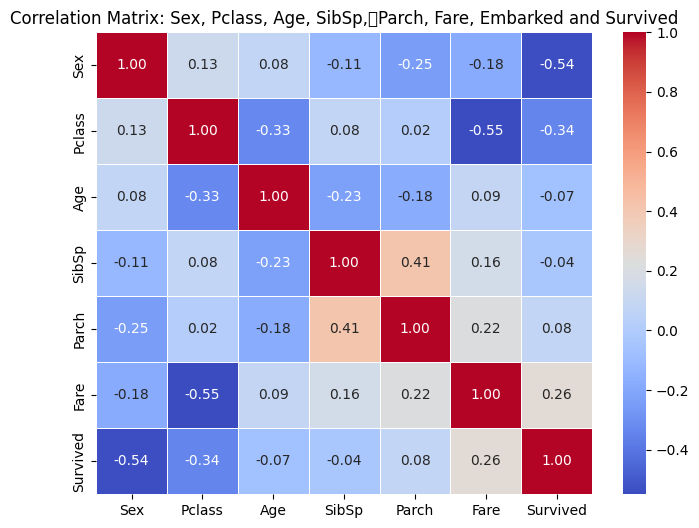

In [65]:
correlation_matrix = features[['Sex', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']].corr()

# 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix: Sex, Pclass, Age, SibSp,	Parch, Fare, Embarked and Survived')
plt.show()

####4. X_train, y_train, X_test, y_test로 나누고 생존여부(Survived)에 따라 각각 분류(SVM, LR, DT, RT, KNN)

In [66]:
# train & test
# 훈련세트와 테스트세트로 나누기
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(passenger_full, passenger_target, test_size=0.2, stratify=passenger_target, random_state=42)

In [67]:
X.dtypes

Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object

In [68]:
from sklearn.preprocessing import StandardScaler

# 데이터 표준화
scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.transform(X_test)

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [70]:
# Support Vector Machine (SVM) with Standardization
from sklearn.svm import SVC
svm_model = SVC(random_state=42)
svm_model.fit(train_scaled, y_train)

svm_predictions = svm_model.predict(test_scaled)
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("SVM Accuracy with Standardization:", svm_accuracy)

print("Confusion Matrix:\n", confusion_matrix(y_test, svm_predictions))
print("Classification Report:\n", classification_report(y_test, svm_predictions))

SVM Accuracy with Standardization: 0.8156424581005587
Confusion Matrix:
 [[101   9]
 [ 24  45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.83      0.65      0.73        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



In [71]:
# Logistic Regression (LR) with Standardization
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(train_scaled, y_train)

lr_predictions = lr_model.predict(test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy with Standardization:", lr_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_predictions))
print("Classification Report:\n", classification_report(y_test, lr_predictions))

Logistic Regression Accuracy with Standardization: 0.7988826815642458
Confusion Matrix:
 [[97 13]
 [23 46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



In [72]:
# Decision Tree (DT) with Standardization
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(train_scaled, y_train)

dt_predictions = dt_model.predict(test_scaled)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy with Standardization:", dt_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_predictions))
print("Classification Report:\n", classification_report(y_test, dt_predictions))

Decision Tree Accuracy with Standardization: 0.8212290502793296
Confusion Matrix:
 [[95 15]
 [17 52]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [73]:
# Random Forest (RF) with Standardization
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(train_scaled, y_train)

rf_predictions = rf_model.predict(test_scaled)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy with Standardization:", rf_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy with Standardization: 0.8044692737430168
Confusion Matrix:
 [[98 12]
 [23 46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [74]:
# K-Nearest Neighbors (KNN) with Standardization
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(train_scaled, y_train)

knn_predictions = knn_model.predict(test_scaled)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("K-Nearest Neighbors Accuracy with Standardization:", knn_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_predictions))
print("Classification Report:\n", classification_report(y_test, knn_predictions))

K-Nearest Neighbors Accuracy with Standardization: 0.8156424581005587
Confusion Matrix:
 [[97 13]
 [20 49]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

